In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

constructors = pd.read_csv('collection/clean_data/constructors.csv')
raceResults = pd.read_csv('collection/clean_data/results.csv')
drivers = pd.read_csv('collection/clean_data/drivers.csv')
races = pd.read_csv('collection/clean_data/races.csv')
circuits = pd.read_csv('collection/clean_data/circuits.csv')

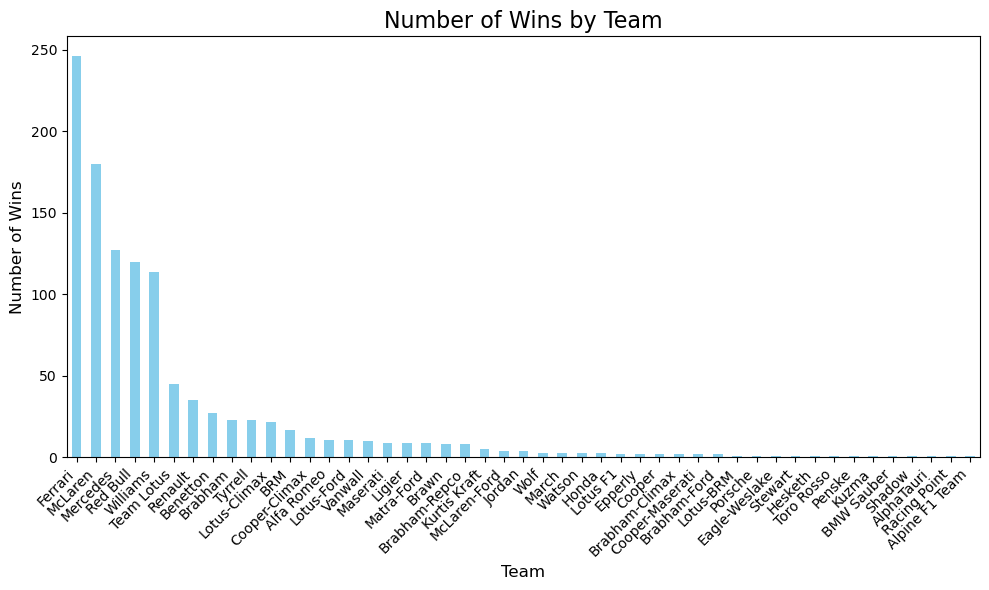

In [15]:
#Change to TOP 10 with lines of wins of the years.  

winners = raceResults[raceResults['position'] == '1']
winners = winners[['constructorId']]

winners = winners.merge(constructors, on='constructorId', how='inner')
team_wins = winners['name'].value_counts()

plt.figure(figsize=(10, 6))
team_wins.plot(kind='bar', color='skyblue')

plt.title('Number of Wins by Team', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

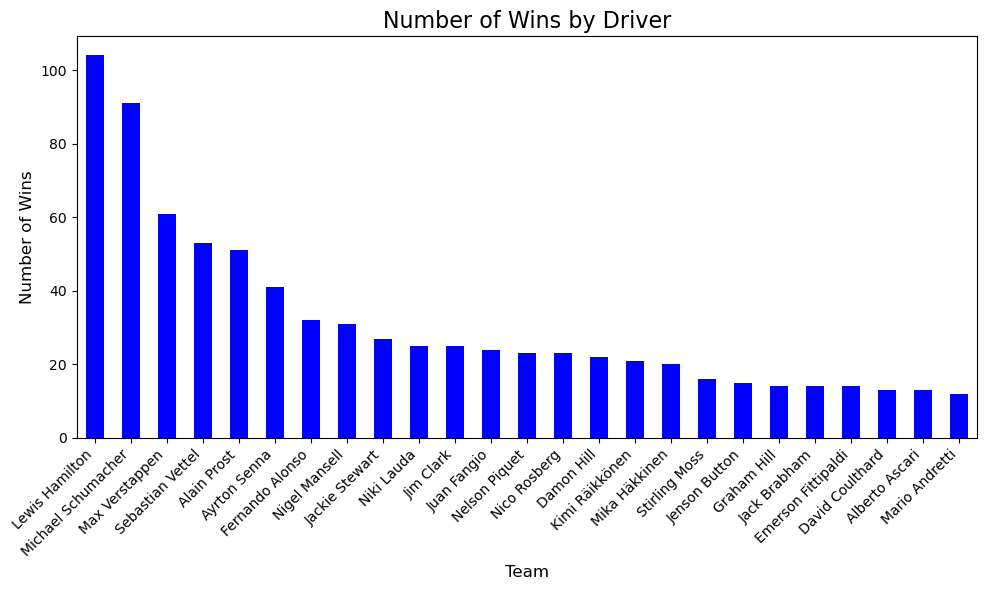

In [5]:
winners = raceResults[raceResults['position'] == '1']
winners = winners[['driverId']]

winners = winners.merge(drivers, on='driverId', how='inner')
winners['Full_Name'] = winners['forename'].astype(str) + ' ' + winners['surname'].astype(str)
driver_wins = winners['Full_Name'].value_counts()
top_25_drivers = driver_wins.head(25)

plt.figure(figsize=(10, 6))
top_25_drivers.plot(kind='bar', color='blue')

plt.title('Number of Wins by Driver', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

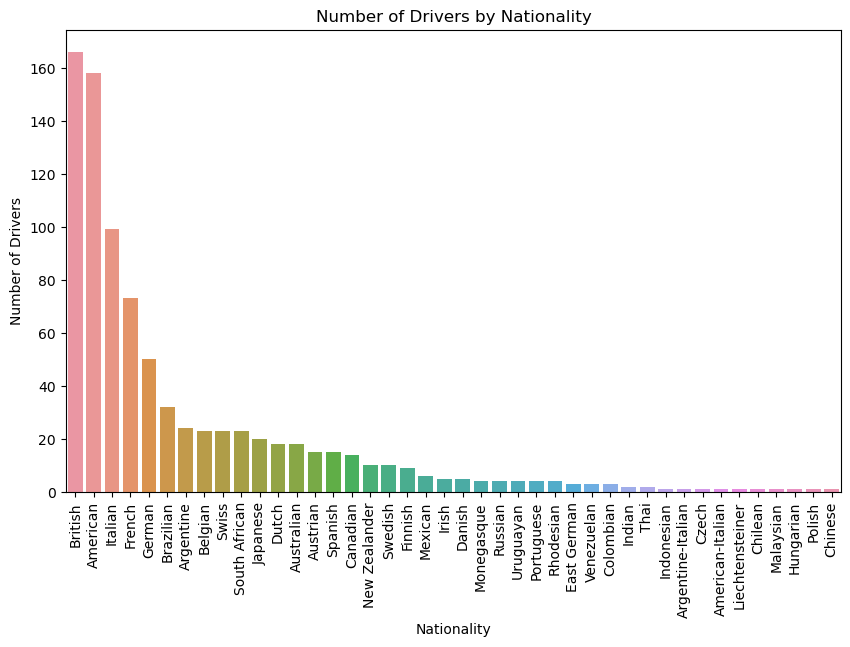

In [21]:
# Number of drivers by Nationaly
nationality_counts = drivers['nationality'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=nationality_counts.index, y=nationality_counts.values)
plt.title('Number of Drivers by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Number of Drivers')
plt.xticks(rotation=90)
plt.show()

In [64]:
unique_years = races['year'].unique()
print("Available years in the dataset: ", unique_years)

races_per_year = races[races['year'] == 2020]

# Select the relevant columns
races_per_year_info = races_per_year[['name', 'date']]

# Display the results
print("Races in 2020:")
print(races_per_year_info.reset_index(drop=True))

Available years in the dataset:  [2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 1996
 1995 1994 1993 1992 1991 1990 2010 1989 1988 1987 1986 1985 1984 1983
 1982 1981 1980 1979 1978 1977 1976 1975 1974 1973 1972 1971 1970 1969
 1968 1967 1966 1965 1964 1963 1962 1961 1960 1959 1958 1957 1956 1955
 1954 1953 1952 1951 1950 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023 2024]
Races in 2020:
                           name        date
0           Austrian Grand Prix  2020-07-05
1            Styrian Grand Prix  2020-07-12
2          Hungarian Grand Prix  2020-07-19
3            British Grand Prix  2020-08-02
4   70th Anniversary Grand Prix  2020-08-09
5            Spanish Grand Prix  2020-08-16
6            Belgian Grand Prix  2020-08-30
7            Italian Grand Prix  2020-09-06
8             Tuscan Grand Prix  2020-09-13
9            Russian Grand Prix  2020-09-27
10             Eifel Grand Prix  2020-10-11
11        Portuguese Grand Prix  2020-10-2

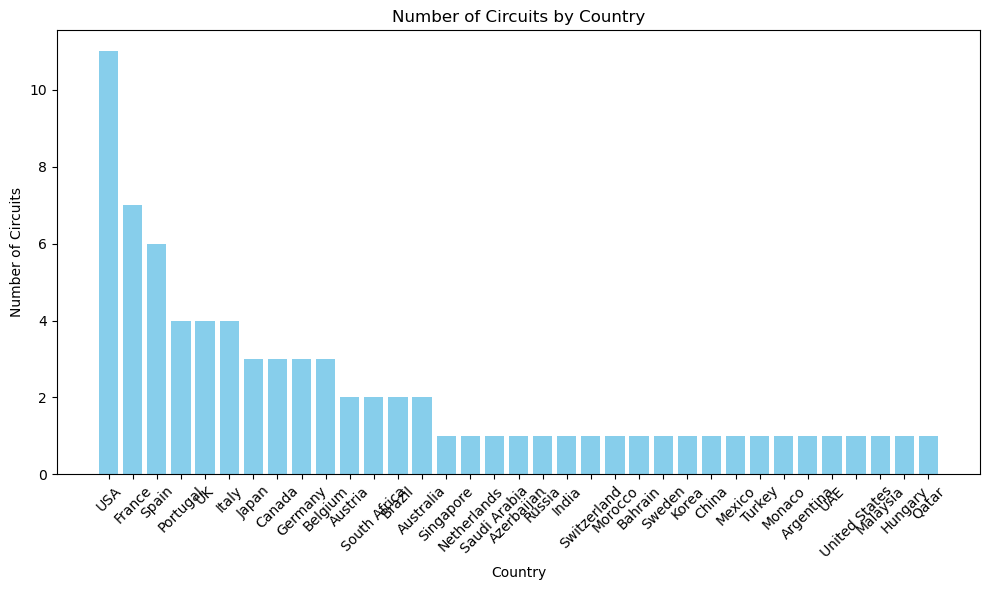

In [71]:
# Count the number of circuits by country
circuit_counts = circuits['country'].value_counts()

# Convert the Series to a DataFrame for easier manipulation
circuit_counts_df = circuit_counts.reset_index()
circuit_counts_df.columns = ['Country', 'Number of Circuits']

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(circuit_counts_df['Country'], circuit_counts_df['Number of Circuits'], color='skyblue')
plt.xlabel('Country')
plt.ylabel('Number of Circuits')
plt.title('Number of Circuits by Country')
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

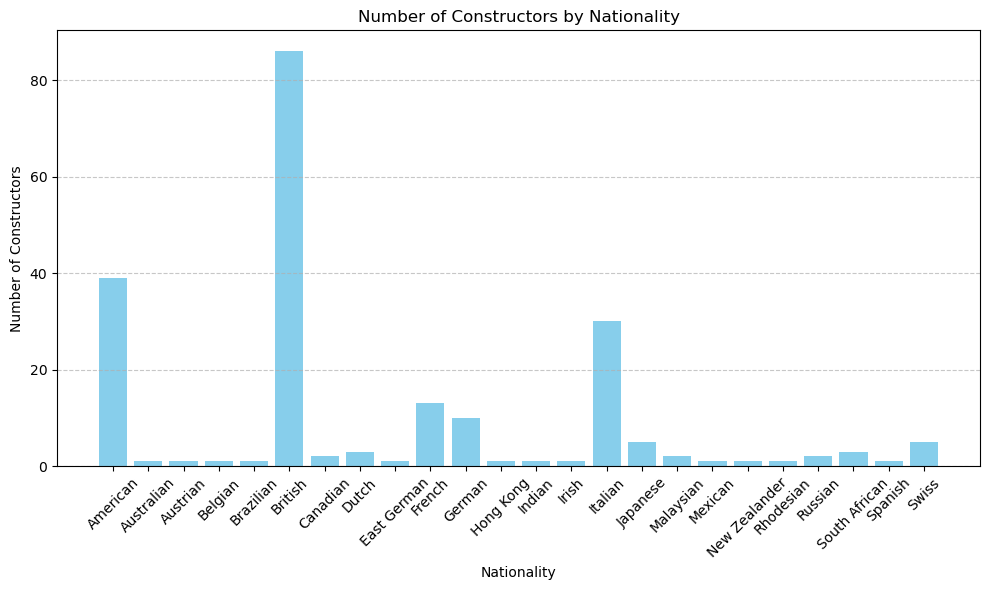

In [75]:
# Group by nationality
constructor_count = (
    constructors.groupby('nationality')
    .agg(
        Number_of_Constructors=('constructorId', 'size'),
        Constructor_Names=('name', lambda x: ', '.join(x))
    )
    .reset_index()
)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(constructor_count['nationality'], constructor_count['Number_of_Constructors'], color='skyblue')
plt.title('Number of Constructors by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Number of Constructors')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()